## Analysis of capabilities of Sec-certs

This notebook showcases the capabilities and contents that can be extracted from Sec-Certs in context of OpenSSL

#### Important imports

In [8]:
from sec_certs.dataset.cc import CCDataset
from sec_certs.dataset.fips import FIPSDataset
import pandas as pd
from src.utils import get_library_mentions
import matplotlib.pyplot as plt
import re

#### Download datasets
Download the most recent datasets for Common Criteria (CC) and FIPS 140 from the Sec-Certs online repository

In [9]:
print("Downloading CC dataset")

cc_dataset = CCDataset.from_web()

print(f"Downloaded {len(cc_dataset)} CC certificates")
print("Saving dataset")

cc_dataset.to_json("./datasets/CC_dataset.json")

print("Dataset saved to ./datasets/CC_dataset.json")

print("Dowloading FIPS dataset")

fips_dataset = FIPSDataset.from_web()

print(f"Downloaded {len(fips_dataset)} FIPS 140 certificates")
print("Saving dataset")

fips_dataset.to_json("./datasets/FIPS_dataset.json")

print("Dataset saved to ./datasets/FIPS_dataset.json")

Downloading: CCDataset:   0%|          | 0.00/193M [00:00<?, ?B/s]

Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7


Downloaded 6729 CC certificates
Saving dataset
Dataset saved to ./datasets/CC_dataset.json
Dowloading FIPS dataset


Downloading: FIPSDataset:   0%|          | 0.00/69.3M [00:00<?, ?B/s]

Dataset was created with sec-certs version 0.3.2.post1.dev139+g8ab79f0c7 (older than your version 0.4.1). To install the matching version: pip install sec-certs==0.3.2.post1.dev139+g8ab79f0c7


Downloaded 5236 FIPS 140 certificates
Saving dataset
Dataset saved to ./datasets/FIPS_dataset.json


### Convert dataset to pandas



In [10]:
cc_pandas = cc_dataset.to_pandas()
fips_pandas = fips_dataset.to_pandas()

plt.rcParams.update({
    "font.size": 14,          # all text
    "axes.titlesize": 16,     # title
    "axes.labelsize": 14,     # axis labels
    "xtick.labelsize": 12,    # tick labels
    "ytick.labelsize": 12,
    "legend.fontsize": 12
})



#### Create dataframes of CC cetrificates containing OpenSSL or alternatives

In [11]:
openssl_df_ext = get_library_mentions(cc_dataset, "OpenSSL")
boringssl_df_ext = get_library_mentions(cc_dataset, "BoringSSL")
wolfssl_df_ext = get_library_mentions(cc_dataset, "wolfSSL")
nss_df_ext = get_library_mentions(cc_dataset, "NSS")
bouncy_castle_df_ext = get_library_mentions(cc_dataset, "BouncyCastle")
libgcrypt_df_ext = get_library_mentions(cc_dataset, "libgcrypt")

combined_df = pd.concat([openssl_df_ext, boringssl_df_ext, wolfssl_df_ext, nss_df_ext, bouncy_castle_df_ext, libgcrypt_df_ext], ignore_index=True)

print(f"Number of certificates with OpenSSL in library {len(openssl_df_ext)}")
print(f"Number of certificates with Libgcrypt in library {len(libgcrypt_df_ext)}")
print(f"Number of certificates with BoringSSL in library {len(boringssl_df_ext)}")
print(f"Number of certificates with WolfSSL in library {len(wolfssl_df_ext)}")
print(f"Number of certificates with NSS in library {len(nss_df_ext)}")
print(f"Number of certificates with BouncyCastle in library {len(bouncy_castle_df_ext)}")

print(f"Number of certificates with any of the libraries: {len(combined_df)}")





Number of certificates with OpenSSL in library 1145
Number of certificates with Libgcrypt in library 47
Number of certificates with BoringSSL in library 86
Number of certificates with WolfSSL in library 10
Number of certificates with NSS in library 76
Number of certificates with BouncyCastle in library 34
Number of certificates with any of the libraries: 1398


#### CC certificates by assurance level

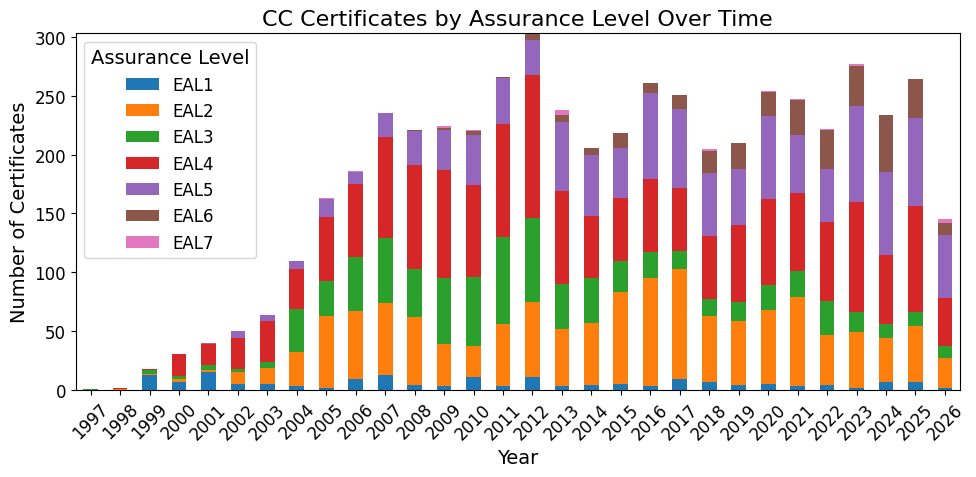

In [12]:
rows = []

for cert in cc_dataset:
    not_valid_before = cert.not_valid_before
    elements = cert.security_level

    eal_raw = next((el for el in elements if el.startswith("EAL")), None)
    if not_valid_before is None or eal_raw is None:
        continue  # skip certs without date or EAL

    m = re.match(r"(EAL[1-7])", eal_raw)
    if not m:
        continue
    eal_norm = m.group(1)
    year = pd.to_datetime(not_valid_before).year
    rows.append({"Year": year, "EAL": eal_norm})

df = pd.DataFrame(rows)

df_counts = (
    df.groupby(["Year", "EAL"])
      .size()
      .unstack(fill_value=0)       
      .sort_index()               
)


ax = df_counts.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("CC Certificates by Assurance Level Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Certificates")
plt.legend(title="Assurance Level")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Manufacturers mentioning OpenSSL in certificates

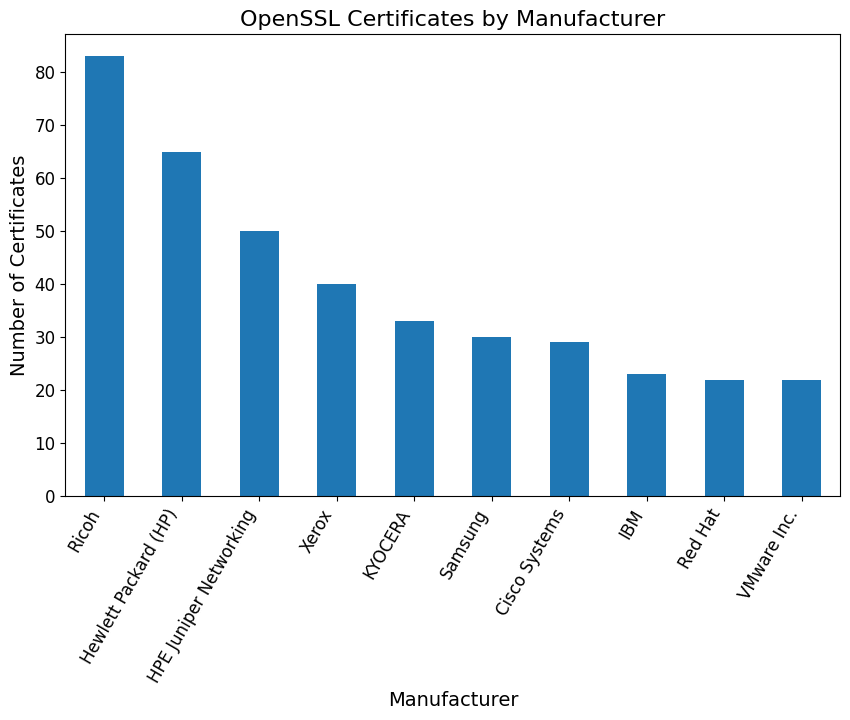

In [15]:
df_manufacturer_counts = openssl_df_ext['Manufacturer'].value_counts()
df_manufacturer_counts.head(10).plot(kind='bar', figsize=(10, 6))
plt.title('OpenSSL Certificates by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of Certificates')
plt.xticks(rotation=60, ha='right')  
plt.show()